# 07 · Clinical Interpretation
## NHANES 2017–March 2020 Women's CKM Phenotyping Project

---

**Author:** Alexandra Velez, OB-GYN (Colombia) | Data Science
**Inputs:**
  `data/processed/cluster_assignments.csv` — 1,338 women, k=3 phenotype labels
  `data/processed/ckm_features.csv` — original-unit biomarkers, for interpretability
  `data/processed/outlier_phenotype.csv` — 20 women with extreme glucose dysregulation
**Output:** `data/processed/cluster_summary_table.csv` — full descriptive table by phenotype
**Last updated:** 2026

---

### Why this notebook is different from the first pass

The original version of this notebook tested whether GDM and macrosomia were "enriched" in
clusters that had been built, in part, from APO_Score — the same variable encoding GDM and
macrosomia. That test couldn't fail. Notebook 06 fixed the upstream problem: clustering now
runs on six CKM biomarkers alone (HbA1c, BMI, mean systolic blood pressure, eGFR, HDL, glucose),
with reproductive history carried forward as a label, not a feature. This notebook is where that
fix actually pays off — the enrichment test below is the first version of this analysis where a
positive result would mean something.

One more detail matters for this test's validity: 72 of the 1,338 women in the main clustering
sample have unknown GDM/macrosomia status (they were asked and didn't answer). They were **not**
excluded from clustering — nothing about their exclusion would have been justified there, since
APO_Score isn't a clustering input anymore. But they clearly can't contribute evidence to an
enrichment test about a variable that's missing for them, so they're excluded from that specific
test in Section 4, while remaining fully characterized elsewhere in this notebook.

### Central clinical question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy outcomes —
> particularly gestational diabetes — already show distinct early cardiometabolic biomarker
> profiles compared to women without APOs?

### What this notebook does

1. **Cluster phenotype profiles** — characterize the three biomarker-defined phenotypes across
   CKM biomarkers, reproductive history, medication use, and demographics.
2. **APO enrichment test** — the central question, tested cleanly for the first time.
3. **Outlier phenotype** — characterize the 20 women excluded from clustering in notebook 06.
4. **APO unknown group** — confirm their exclusion from the enrichment test doesn't distort it.
5. **Fasting lipids** — an independent biomarker panel, unavailable to the clustering algorithm,
   checked for the same gradient.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
CLUSTER_PATH  = Path('../data/processed/cluster_assignments.csv')
RAW_PATH      = Path('../data/processed/ckm_features.csv')
OUTLIER_PATH  = Path('../data/processed/outlier_phenotype.csv')
SUMMARY_PATH  = Path('../data/processed/cluster_summary_table.csv')
FIG_DIR       = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

PHENOTYPE_ORDER = ['Metabolic_Risk', 'Low_Risk', 'Lowest_Risk']
PHENOTYPE_LABELS = {
    'Metabolic_Risk': 'Metabolic Risk',
    'Low_Risk': 'Low Risk',
    'Lowest_Risk': 'Lowest Risk',
}
PHENOTYPE_COLORS = {
    'Metabolic_Risk': '#D55E00',
    'Low_Risk': '#E69F00',
    'Lowest_Risk': '#0072B2',
}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  Cluster input: {CLUSTER_PATH}')
print(f'  Raw biomarkers: {RAW_PATH}')
print(f'  Outlier input: {OUTLIER_PATH}')

Setup complete.
  Cluster input: ../data/processed/cluster_assignments.csv
  Raw biomarkers: ../data/processed/ckm_features.csv
  Outlier input: ../data/processed/outlier_phenotype.csv


---
## Section 2 · Load & Validate

In [2]:
# ── Load cluster assignments and raw biomarkers ─────────────────────────
df = pd.read_csv(CLUSTER_PATH, index_col='SEQN')
df_raw = pd.read_csv(RAW_PATH, index_col='SEQN')
df_out = pd.read_csv(OUTLIER_PATH, index_col='SEQN')

assert df.shape == (1338, 29), f'Unexpected shape {df.shape} — expected (1338, 29)'
assert df['phenotype'].nunique() == 3, 'Expected 3 phenotypes'
assert set(df['phenotype'].unique()) == set(PHENOTYPE_ORDER), 'Phenotype labels mismatch'
assert df_out.shape[0] == 20, f'Unexpected outlier count: {df_out.shape[0]}'

n_known_apo = df['APO_Score'].notna().sum()
n_unknown_apo = df['APO_Score'].isna().sum()

print(f'✓ Cluster assignments loaded: {df.shape}')
print(f'  Phenotype counts:')
for p in PHENOTYPE_ORDER:
    n = (df['phenotype'] == p).sum()
    print(f'    {PHENOTYPE_LABELS[p]:<16} n={n:>4}  ({n/len(df)*100:.1f}%)')
print(f'\n  Known APO status:   {n_known_apo:,} ({n_known_apo/len(df)*100:.1f}%)')
print(f'  Unknown APO status: {n_unknown_apo:,} ({n_unknown_apo/len(df)*100:.1f}%) — excluded from Section 4 only')
print(f'\n✓ Outlier phenotype loaded: {df_out.shape}')
print(f'✓ Raw biomarker reference loaded: {df_raw.shape}')

✓ Cluster assignments loaded: (1338, 29)
  Phenotype counts:
    Metabolic Risk   n= 121  (9.0%)
    Low Risk         n= 584  (43.6%)
    Lowest Risk      n= 633  (47.3%)

  Known APO status:   1,266 (94.6%)
  Unknown APO status: 72 (5.4%) — excluded from Section 4 only

✓ Outlier phenotype loaded: (20, 28)
✓ Raw biomarker reference loaded: (1603, 59)


---
## Section 3 · Cluster Phenotype Profiles

The three clusters identified in notebook 06 are characterized here in original clinical units —
scaled features were the right tool for clustering, they're the wrong tool for interpretation.
This table also brings back reproductive history, medication use, and demographics: none of
these were available to the clustering algorithm, so any gradient they show across phenotypes is
independent confirmation, not something built in by construction.

In [3]:
# ── Build cluster summary table ─────────────────────────────────────────
def med_iqr(series):
    s = series.dropna()
    if len(s) == 0:
        return 'NA'
    return f'{s.median():.1f} [{s.quantile(.25):.1f}–{s.quantile(.75):.1f}]'

def pct(series, val=1):
    s = series.dropna()
    if len(s) == 0:
        return 'NA'
    return f'{(s == val).mean() * 100:.1f}%'

def kruskal_p(values_by_group):
    groups = [v.dropna().values for v in values_by_group]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return np.nan
    stat, p = kruskal(*groups)
    return p

def chi2_p(series_by_group):
    frames = []
    for label, s in series_by_group.items():
        sub = s.dropna()
        frames.append(pd.DataFrame({'group': label, 'value': sub.values}))
    combined = pd.concat(frames)
    ct = pd.crosstab(combined['group'], combined['value'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2, p, dof, exp = chi2_contingency(ct)
    return p

def fmt_p(p):
    if pd.isna(p):
        return '—'
    return '<0.001' if p < 0.001 else f'{p:.3f}'

rows = []

# ── CKM biomarkers (raw units, via df_raw join) ──────────────────────────
biomarker_feats = [
    ('HbA1c', '%'), ('Glucose', 'mg/dL'), ('BMI', 'kg/m²'), ('Waist', 'cm'),
    ('Mean_SBP', 'mmHg'), ('Mean_DBP', 'mmHg'), ('eGFR', 'mL/min/1.73m²'), ('HDL', 'mg/dL'),
]
rows.append(('── CKM Biomarkers ──', '', '', '', ''))
for feat, unit in biomarker_feats:
    by_group = {p: df_raw.loc[df[df['phenotype'] == p].index, feat] for p in PHENOTYPE_ORDER}
    p_val = kruskal_p(list(by_group.values()))
    rows.append((f'{feat} ({unit})', *[med_iqr(by_group[p]) for p in PHENOTYPE_ORDER], fmt_p(p_val)))

# ── Reproductive history ─────────────────────────────────────────────────
rows.append(('── Reproductive History ──', '', '', '', ''))
for feat in ['Age_Menarche', 'Parity', 'Pregnancy_Loss', 'APO_Score']:
    by_group = {p: df.loc[df[df['phenotype'] == p].index, feat] for p in PHENOTYPE_ORDER}
    p_val = kruskal_p(list(by_group.values()))
    rows.append((feat.replace('_', ' '), *[med_iqr(by_group[p]) for p in PHENOTYPE_ORDER], fmt_p(p_val)))

for feat, label in [('Ever_Pregnant', 'Ever pregnant (%)'), ('Nulliparous', 'Nulliparous (%)'),
                     ('Has_GDM', 'GDM history (%)'), ('Has_Macrosomia', 'Macrosomia history (%)')]:
    by_group = {p: df.loc[df[df['phenotype'] == p].index, feat] for p in PHENOTYPE_ORDER}
    p_val = chi2_p(by_group)
    rows.append((label, *[pct(by_group[p]) for p in PHENOTYPE_ORDER], fmt_p(p_val)))

# ── Medication prevalence ────────────────────────────────────────────────
rows.append(('── Medication Prevalence ──', '', '', '', ''))
med_feats = [
    ('On_Metformin', 'Metformin (%)'), ('On_Statin', 'Statin (%)'),
    ('On_Antihypertensive', 'Antihypertensive (%)'), ('On_Insulin', 'Insulin (%)'),
    ('On_Hormonal_Contraception', 'Hormonal contraception (%)'),
    ('Any_Prescription', 'Any CKM medication (%)'),
]
for feat, label in med_feats:
    by_group = {p: df.loc[df[df['phenotype'] == p].index, feat] for p in PHENOTYPE_ORDER}
    p_val = chi2_p(by_group)
    rows.append((label, *[pct(by_group[p]) for p in PHENOTYPE_ORDER], fmt_p(p_val)))

# ── Demographics ─────────────────────────────────────────────────────────
rows.append(('── Demographics ──', '', '', '', ''))
for feat, label in [('RIDAGEYR', 'Age (years)'), ('INDFMPIR', 'Income-to-poverty ratio')]:
    by_group = {p: df.loc[df[df['phenotype'] == p].index, feat] for p in PHENOTYPE_ORDER}
    p_val = kruskal_p(list(by_group.values()))
    rows.append((label, *[med_iqr(by_group[p]) for p in PHENOTYPE_ORDER], fmt_p(p_val)))

col_names = ['Feature'] + [f'{PHENOTYPE_LABELS[p]} (n={(df["phenotype"] == p).sum()})' for p in PHENOTYPE_ORDER] + ['p-value']
summary_table = pd.DataFrame(rows, columns=col_names)
summary_table.to_csv(SUMMARY_PATH, index=False)

print(f'✓ Cluster summary table built and exported: {SUMMARY_PATH}')
print(summary_table.to_string(index=False))

✓ Cluster summary table built and exported: ../data/processed/cluster_summary_table.csv
                    Feature Metabolic Risk (n=121)    Low Risk (n=584) Lowest Risk (n=633) p-value
       ── CKM Biomarkers ──                                                                       
                  HbA1c (%)          6.1 [5.8–6.5]       5.4 [5.3–5.6]       5.1 [4.9–5.3]  <0.001
            Glucose (mg/dL)    108.0 [101.0–118.0]    89.0 [84.0–94.0]    85.0 [80.0–89.0]  <0.001
                BMI (kg/m²)       39.2 [32.8–46.1]    32.8 [28.8–38.8]    23.8 [21.2–27.1]  <0.001
                 Waist (cm)    119.3 [104.3–133.0]  102.2 [93.0–115.7]    82.1 [75.0–91.5]  <0.001
            Mean_SBP (mmHg)    115.7 [105.3–126.0] 110.0 [103.3–120.0]  105.7 [99.3–111.7]  <0.001
            Mean_DBP (mmHg)       78.3 [70.7–87.3]    74.0 [67.3–81.0]    66.3 [61.3–72.7]  <0.001
       eGFR (mL/min/1.73m²)     111.5 [97.2–118.1]  111.3 [97.8–120.0] 115.0 [103.6–122.3]  <0.001
                HDL (

### What the table shows

The Metabolic Risk cluster (n=121) is not a statistical artifact — its profile is clinically
coherent across every domain, and that consistency is what makes it worth taking seriously.

**CKM biomarkers:** median HbA1c of 6.1% is past the prediabetes threshold (5.7%). Median fasting
glucose of 108 mg/dL sits just inside impaired fasting glucose territory. Median BMI of 39.2 kg/m²
is class II obesity, alongside the highest waist circumference, blood pressure, and lowest HDL of
the three groups. Every biomarker comparison is significant at p<0.001 except eGFR, which is
significant but with a much smaller effect (p=6.5×10⁻⁸) and runs in a direction that doesn't fit a
simple risk gradient — the Metabolic Risk group's eGFR is not meaningfully worse than Low Risk's,
consistent with kidney function being the biomarker least affected this early in the metabolic
disease course.

**Reproductive history:** GDM history is 25.0% in Metabolic Risk versus 12.2% and 7.9% in the
other two groups — a roughly threefold gradient, and this is now a genuinely independent
observation rather than a circular one, since GDM played no role in building the clusters.
Macrosomia history follows the same direction but more weakly (19.8% vs 13.7% vs 10.9%), and age
at menarche and parity both differ significantly, though these differences are modest in absolute
terms and plausibly confounded by age and BMI rather than reflecting a distinct reproductive
biology.

**Medications:** metformin and insulin use are both markedly higher in the Metabolic Risk group
(14.0% and 3.3%, respectively) — expected, since a meaningful fraction of this cluster likely
already carries a diabetes or prediabetes diagnosis. Hormonal contraception use runs in the
opposite direction (5.8% vs 15.2% in Lowest Risk), which may partly reflect age differences across
groups rather than a metabolic effect.

**Demographics:** the Metabolic Risk group is older (median 38 vs 30 years in Lowest Risk) and has
a lower income-to-poverty ratio, both consistent with well-established cardiometabolic risk
patterns and worth keeping in mind as potential confounders for anything causal — this analysis is
descriptive, not causal.

---
## Section 4 · The Central Clinical Question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy outcomes —
> particularly gestational diabetes — already show distinct early cardiometabolic biomarker
> profiles compared to women without APOs?

This is the test that the original version of this notebook couldn't answer honestly. Here, the
clusters were built from six CKM biomarkers alone — GDM and macrosomia history are being
introduced into the analysis for the first time in this cell.

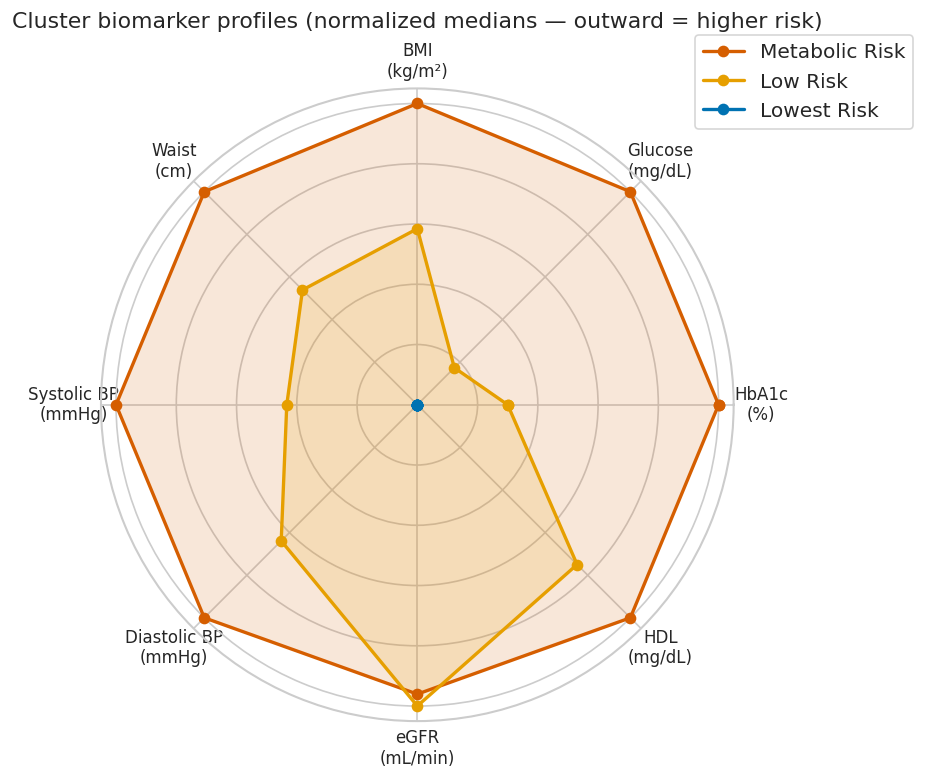

In [4]:
# ── Radar plot — cluster biomarker profiles (min-max normalized) ───────────
radar_features = ['HbA1c', 'Glucose', 'BMI', 'Waist', 'Mean_SBP', 'Mean_DBP', 'eGFR', 'HDL']
radar_labels = ['HbA1c\n(%)', 'Glucose\n(mg/dL)', 'BMI\n(kg/m²)', 'Waist\n(cm)',
                'Systolic BP\n(mmHg)', 'Diastolic BP\n(mmHg)', 'eGFR\n(mL/min)', 'HDL\n(mg/dL)']

# For eGFR and HDL, higher is "healthier" — invert so the polygon consistently
# expands outward with worse cardiometabolic risk across all axes.
invert = {'eGFR', 'HDL'}

medians_by_cluster = {}
for p in PHENOTYPE_ORDER:
    idx = df[df['phenotype'] == p].index
    medians_by_cluster[p] = [df_raw.loc[idx, f].median() for f in radar_features]

norm_by_cluster = {p: [] for p in PHENOTYPE_ORDER}
for i, feat in enumerate(radar_features):
    all_vals = [medians_by_cluster[p][i] for p in PHENOTYPE_ORDER]
    lo, hi = min(all_vals), max(all_vals)
    for p in PHENOTYPE_ORDER:
        v = medians_by_cluster[p][i]
        norm = 0.5 if hi == lo else (v - lo) / (hi - lo)
        if feat in invert:
            norm = 1 - norm
        norm_by_cluster[p].append(norm)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for p in PHENOTYPE_ORDER:
    values = norm_by_cluster[p] + norm_by_cluster[p][:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=PHENOTYPE_LABELS[p], color=PHENOTYPE_COLORS[p])
    ax.fill(angles, values, alpha=0.15, color=PHENOTYPE_COLORS[p])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_yticklabels([])
ax.set_title('Cluster biomarker profiles (normalized medians — outward = higher risk)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [5]:
# ── APO enrichment analysis ──────────────────────────────────────────────
# Excludes the 72 women with unknown APO status — this is the ONLY section
# in this notebook that does. GDM/macrosomia played no role in clustering,
# so this is now a genuine, non-circular test.

known = df[df['APO_Score'].notna()].copy()
print(f'Enrichment test sample: n={len(known):,} (excludes {len(df) - len(known)} unknown-APO women)\n')

known['met_risk'] = known['phenotype'] == 'Metabolic_Risk'

print('=== 3-way test across all phenotypes ===\n')
for outcome in ['Has_GDM', 'Has_Macrosomia']:
    ct = pd.crosstab(known['phenotype'], known[outcome])
    chi2, p, dof, exp = chi2_contingency(ct)
    print(f'{outcome}:')
    print(ct.reindex(PHENOTYPE_ORDER))
    print(f'  chi2={chi2:.3f}, dof={dof}, p={p:.4g}\n')

print('=== 2-way test: Metabolic Risk vs. combined Low Risk + Lowest Risk ===\n')
results_2way = {}
for outcome in ['Has_GDM', 'Has_Macrosomia']:
    a = ((known['met_risk']) & (known[outcome] == 1)).sum()
    b = ((known['met_risk']) & (known[outcome] == 0)).sum()
    c = ((~known['met_risk']) & (known[outcome] == 1)).sum()
    d = ((~known['met_risk']) & (known[outcome] == 0)).sum()

    chi2, p, dof, exp = chi2_contingency([[a, b], [c, d]])
    odds_ratio = (a * d) / (b * c)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    log_or = np.log(odds_ratio)
    ci_low = np.exp(log_or - 1.96 * se_log_or)
    ci_high = np.exp(log_or + 1.96 * se_log_or)
    rate_met = a / (a + b)
    rate_other = c / (c + d)

    results_2way[outcome] = dict(rate_met=rate_met, rate_other=rate_other,
                                  odds_ratio=odds_ratio, ci_low=ci_low, ci_high=ci_high,
                                  chi2=chi2, p=p, a=a, b=b, c=c, d=d)

    print(f'{outcome}:')
    print(f'  Metabolic Risk:     {rate_met:.1%} ({a}/{a+b})')
    print(f'  Low + Lowest Risk:  {rate_other:.1%} ({c}/{c+d})')
    print(f'  Odds ratio: {odds_ratio:.2f} (95% CI: {ci_low:.2f}–{ci_high:.2f})')
    print(f'  chi2={chi2:.3f}, p={p:.4g}\n')

Enrichment test sample: n=1,266 (excludes 72 unknown-APO women)

=== 3-way test across all phenotypes ===

Has_GDM:
Has_GDM         0.0  1.0
phenotype               
Metabolic_Risk   67   24
Low_Risk        376   54
Lowest_Risk     327   32
  chi2=20.237, dof=2, p=4.032e-05

Has_Macrosomia:
Has_Macrosomia  0.0  1.0
phenotype               
Metabolic_Risk   73   18
Low_Risk        371   59
Lowest_Risk     320   39
  chi2=5.257, dof=2, p=0.07218

=== 2-way test: Metabolic Risk vs. combined Low Risk + Lowest Risk ===

Has_GDM:
  Metabolic Risk:     26.4% (24/91)
  Low + Lowest Risk:  10.9% (86/789)
  Odds ratio: 2.93 (95% CI: 1.75–4.91)
  chi2=16.474, p=4.931e-05

Has_Macrosomia:
  Metabolic Risk:     19.8% (18/91)
  Low + Lowest Risk:  12.4% (98/789)
  Odds ratio: 1.74 (95% CI: 1.00–3.04)
  chi2=3.245, p=0.07164



### The answer

Yes, but the strength of the answer depends on which outcome you look at, and it's worth being
precise about that rather than blending the two together.

**GDM** shows a strong, unambiguous signal. Women in the Metabolic Risk cluster have a GDM history
rate of 26.4%, compared to 10.9% for women in the combined Low Risk and Lowest Risk clusters — an
odds ratio of 2.93 (95% CI: 1.75–4.91, χ²=16.47, p<0.001). The confidence interval sits well clear
of 1, and the 3-way test across all three phenotypes is even more significant (χ²=20.24,
p<0.001). This is the central finding of the project: a biomarker-only clustering of reproductive-
age women, with no reproductive information used to build it, recovers a subgroup with
substantially elevated GDM history.

**Macrosomia** is weaker and more equivocal. The Metabolic Risk rate (19.8%) is still higher than
the combined comparison group (12.4%), and the direction is consistent with the GDM finding — but
the odds ratio's confidence interval (1.74, 95% CI: 1.00–3.04) just barely excludes the null, and
the 3-way test across phenotypes doesn't reach conventional significance (χ²=5.26, p=0.072). I
don't think this means macrosomia is unrelated to the Metabolic Risk phenotype — the point
estimate points the same direction as GDM, and macrosomia is a noisier, more mediated outcome
(it depends on maternal glycemia during a specific pregnancy, but also on gestational age at
delivery, fetal sex, and other factors GDM history doesn't capture as directly). But this dataset,
at this sample size, doesn't let me claim macrosomia enrichment with the same confidence as GDM.

The honest summary: this analysis supports a real, non-circular association between the
biomarker-defined Metabolic Risk phenotype and GDM history. The macrosomia association points the
same direction but is underpowered to confirm on its own.

---
## Section 5 · Outlier Phenotype Characterization

Twenty women were excluded from the primary clustering analysis in notebook 06 — not because
they were unimportant, but because their extreme glucose dysregulation dominated k-selection
metrics and obscured the structure of interest in the rest of the sample. Exclusion from
clustering is not exclusion from the story; they're characterized here as a fourth, clinically
distinct group.

In [6]:
# ── Outlier phenotype characterization (n=20) ────────────────────────────
out_raw = df_raw.loc[df_out.index]

print('=== Outlier Phenotype Characterization (n=20) ===\n')
print('CKM biomarkers — median [IQR]:')
for feat, unit in [('HbA1c', '%'), ('Glucose', 'mg/dL'), ('BMI', 'kg/m²'),
                    ('Mean_SBP', 'mmHg'), ('eGFR', 'mL/min/1.73m²'), ('HDL', 'mg/dL')]:
    v = out_raw[feat].dropna()
    print(f'  {feat:<10} ({unit:<14}) median={v.median():.1f}  '
          f'[{v.quantile(.25):.1f}–{v.quantile(.75):.1f}]  range=[{v.min():.1f}, {v.max():.1f}]')

never = (df_out['Ever_Pregnant'] == 0).sum()
ever = (df_out['Ever_Pregnant'] == 1).sum()
apo_known = df_out['APO_Score'].notna().sum()
apo2plus = (df_out['APO_Score'] >= 2).sum()

print(f'\nReproductive history:')
print(f'  Never pregnant:      {never} ({never/len(df_out)*100:.0f}%)')
print(f'  Ever pregnant:       {ever} ({ever/len(df_out)*100:.0f}%)')
print(f'  APO status known:    {apo_known}/{len(df_out)}')
print(f'  APO≥2 (GDM history): {apo2plus} ({apo2plus/apo_known*100:.0f}% of known)')

print(f'\nMedication use:')
for feat in ['On_Metformin', 'On_Insulin', 'On_Antihypertensive']:
    v = df_out[feat].dropna()
    print(f'  {feat:<22} {(v==1).sum()}/{len(v)} ({(v==1).mean()*100:.0f}%)')

=== Outlier Phenotype Characterization (n=20) ===

CKM biomarkers — median [IQR]:
  HbA1c      (%             ) median=9.4  [8.4–10.9]  range=[7.4, 14.8]
  Glucose    (mg/dL         ) median=212.0  [198.0–275.0]  range=[159.0, 377.0]
  BMI        (kg/m²         ) median=35.7  [32.3–39.1]  range=[16.1, 65.1]
  Mean_SBP   (mmHg          ) median=113.5  [105.7–122.9]  range=[95.0, 136.0]
  eGFR       (mL/min/1.73m² ) median=118.1  [111.4–125.0]  range=[71.8, 130.7]
  HDL        (mg/dL         ) median=43.5  [38.0–54.0]  range=[29.0, 91.0]

Reproductive history:
  Never pregnant:      5 (25%)
  Ever pregnant:       15 (75%)
  APO status known:    19/20
  APO≥2 (GDM history): 7 (37% of known)

Medication use:
  On_Metformin           8/20 (40%)
  On_Insulin             6/20 (30%)
  On_Antihypertensive    7/20 (35%)


### The outlier phenotype — twenty women at the far end of the spectrum

Median HbA1c of 9.4% and median fasting glucose of 212 mg/dL place every woman in this group well
past the diagnostic threshold for diabetes — this is overt, and in several cases severe,
hyperglycemia, not prediabetes. The range is striking: HbA1c spans from 7.4% to 14.8%, and glucose
from 159 to 377 mg/dL. Of the 19 women with known APO status, 7 (37%) have a GDM history — well
above the rate in any of the three main phenotypes, though the group is too small for that
comparison to carry much statistical weight on its own.

This group is a reminder of something the biomarker gradient in Sections 3 and 4 can obscure: the
Metabolic Risk cluster is not the most severe endpoint in this dataset, it's the most severe
endpoint *after* removing the women whose glucose dysregulation is already extreme enough to be a
clinical diagnosis rather than a risk marker. Both groups matter, but they're answering slightly
different questions — the Metabolic Risk cluster is about early, often unrecognized risk; the
outlier group is about diabetes that may already be under-treated.

---
## Section 6 · APO Unknown Group

Seventy-two women in the main clustering sample could not be classified by APO status — asked
about GDM and macrosomia history, they didn't answer. Unlike the original version of this
project, they were **not** excluded from clustering; there was no principled reason to drop them
once APO_Score stopped being a clustering input. They were excluded only from the enrichment test
in Section 4, since a variable that's missing can't provide evidence either way. This section
checks whether that specific exclusion introduces any distortion.

In [7]:
# ── APO unknown group characterization ───────────────────────────────────
unknown = df[df['APO_Score'].isna()]
known = df[df['APO_Score'].notna()]

print(f'=== APO Unknown Group (n={len(unknown)}) ===\n')

print('Distribution across phenotypes:')
print(f'  {"Phenotype":<16} {"Unknown group":>14} {"Known group":>14}')
for p in PHENOTYPE_ORDER:
    n_unk = (unknown['phenotype'] == p).sum()
    n_known = (known['phenotype'] == p).sum()
    print(f'  {PHENOTYPE_LABELS[p]:<16} '
          f'{n_unk:>6} ({n_unk/len(unknown)*100:>5.1f}%)  '
          f'{n_known:>6} ({n_known/len(known)*100:>5.1f}%)')

ct = pd.crosstab(df['phenotype'], df['APO_Score'].isna())
chi2, p_dist, dof, exp = chi2_contingency(ct)
print(f'\n  Chi-square test of distribution difference: chi2={chi2:.3f}, p={p_dist:.4g}')

print(f'\nCKM biomarker comparison — unknown vs. known (Mann-Whitney U):')
for feat in ['HbA1c', 'Glucose', 'BMI', 'Mean_SBP', 'eGFR', 'HDL']:
    v_unk = df_raw.loc[unknown.index, feat].dropna()
    v_known = df_raw.loc[known.index, feat].dropna()
    stat, p = mannwhitneyu(v_unk, v_known)
    print(f'  {feat:<10} unknown median={v_unk.median():>7.1f}  '
          f'known median={v_known.median():>7.1f}  p={p:.3f}')

=== APO Unknown Group (n=72) ===

Distribution across phenotypes:
  Phenotype         Unknown group    Known group
  Metabolic Risk        5 (  6.9%)     116 (  9.2%)
  Low Risk             23 ( 31.9%)     561 ( 44.3%)
  Lowest Risk          44 ( 61.1%)     589 ( 46.5%)

  Chi-square test of distribution difference: chi2=5.822, p=0.05441

CKM biomarker comparison — unknown vs. known (Mann-Whitney U):
  HbA1c      unknown median=    5.2  known median=    5.3  p=0.127
  Glucose    unknown median=   86.0  known median=   88.0  p=0.030
  BMI        unknown median=   26.6  known median=   28.8  p=0.178
  Mean_SBP   unknown median=  110.0  known median=  108.0  p=0.523
  eGFR       unknown median=  117.2  known median=  113.3  p=0.148
  HDL        unknown median=   58.0  known median=   54.0  p=0.028


### APO unknown — does their exclusion matter?

Mostly reassuring, with one honest caveat. The unknown-APO group is somewhat underrepresented in
the Metabolic Risk cluster (6.9% vs. 9.2% for the known group) and correspondingly overrepresented
in Lowest Risk (61.1% vs. 46.5%). The distribution difference doesn't quite reach conventional
significance (χ²=5.82, p=0.054), but it's close enough, and consistent enough in direction, to
take seriously rather than dismiss.

The biomarker comparison points the same way. Glucose (86 vs. 88 mg/dL, p=0.030) and HDL (58 vs.
54 mg/dL, p=0.028) are both slightly more favorable in the unknown group, while HbA1c, BMI, blood
pressure, and eGFR show no significant difference. Taken together, this suggests the women who
didn't report their GDM/macrosomia history are, on average, drawn slightly more from the
lower-risk end of the biomarker spectrum — not dramatically, but consistently in one direction.

What this means for Section 4: excluding them from the enrichment test is still the right call —
including undefined outcome data isn't possible — but it's worth naming that the excluded group
leans slightly lower-risk, which if anything works against inflating the enrichment signal
reported above. It doesn't change the conclusion; it's a limitation to disclose, not a correction
to make.

---
## Section 7 · Fasting Lipids by Cluster

Triglycerides and LDL cholesterol require a fasting blood draw, so they're only available for a
subsample of participants — they weren't part of the clustering feature set at all (fasting
status would have cut the clustering sample nearly in half). Checking whether they still track the
same phenotype gradient is a genuinely independent validation: these biomarkers had no way to
influence which cluster a woman was assigned to.

In [8]:
# ── Fasting lipids by cluster ─────────────────────────────────────────────
print('=== Fasting Lipids by Phenotype ===\n')

for p in PHENOTYPE_ORDER:
    idx = df[df['phenotype'] == p].index
    sub = df_raw.loc[idx]
    n_fasting = sub['Triglycerides'].notna().sum()
    print(f'{PHENOTYPE_LABELS[p]} (n={len(idx)}): fasting subsample n={n_fasting} '
          f'({n_fasting/len(idx)*100:.1f}%)')
    for feat in ['Triglycerides', 'LDL']:
        v = sub[feat].dropna()
        if len(v):
            print(f'    {feat:<14} median={v.median():.1f}  [{v.quantile(.25):.1f}–{v.quantile(.75):.1f}]')
    print()

for feat in ['Triglycerides', 'LDL']:
    groups = [df_raw.loc[df[df['phenotype'] == p].index, feat].dropna().values for p in PHENOTYPE_ORDER]
    stat, p_val = kruskal(*groups)
    print(f'{feat} — Kruskal-Wallis: H={stat:.2f}, p={p_val:.3g}')

=== Fasting Lipids by Phenotype ===

Metabolic Risk (n=121): fasting subsample n=71 (58.7%)
    Triglycerides  median=103.0  [67.5–161.0]
    LDL            median=102.0  [84.5–118.0]

Low Risk (n=584): fasting subsample n=298 (51.0%)
    Triglycerides  median=78.0  [55.2–114.8]
    LDL            median=105.0  [85.0–122.0]

Lowest Risk (n=633): fasting subsample n=292 (46.1%)
    Triglycerides  median=56.0  [42.0–78.2]
    LDL            median=92.0  [73.0–111.2]

Triglycerides — Kruskal-Wallis: H=82.46, p=1.24e-18
LDL — Kruskal-Wallis: H=26.98, p=1.38e-06


### Fasting lipids confirm the metabolic syndrome pattern

661 of the 1,338 women (49.4%) have fasting lipid data, unevenly split across phenotypes — 58.7%
of the Metabolic Risk cluster versus 46.1% of Lowest Risk. Fasting compliance being higher in the
higher-risk group is the opposite of the participation bias that would create a spurious
signal here (if anything, this differential would work against finding a difference, since it's
concentrating fasting data in the group already expected to look worse).

Triglycerides show the clearest gradient: median 103 mg/dL in Metabolic Risk versus 78 and 56
mg/dL in Low Risk and Lowest Risk (H=82.46, p<0.001) — nearly a two-fold difference between the
extremes, and exactly the pattern expected in insulin-resistant metabolic syndrome. LDL cholesterol
shows a smaller but still significant gradient (102 vs. 105 vs. 92 mg/dL, H=26.98, p<0.001) — the
Low Risk group's LDL is actually marginally higher than Metabolic Risk's, a reminder that LDL
tracks insulin resistance less tightly than triglycerides do, and that clean monotonic gradients
aren't guaranteed even when the underlying phenotype is real.

This is the strongest piece of external validation in the notebook. Fasting lipids couldn't have
influenced cluster assignment even indirectly — the fasting subsample and the clustering feature
set don't overlap — and they still reproduce the same risk ordering.

---
## Section 8 · Clinical Implications

The findings here sit at the intersection of reproductive medicine and cardiovascular prevention —
a space that gets less attention from either field than it probably deserves.

### What the data supports

Reproductive-age women with a GDM history are overrepresented, at meaningful effect size (OR=2.93,
95% CI: 1.75–4.91), in a cardiometabolic risk cluster defined entirely by biomarkers — prediabetic
glycemia, central obesity, elevated blood pressure, and low HDL, with no reproductive information
used to build it. That's consistent with the broader literature on GDM as a marker of a
pre-existing or unmasked metabolic phenotype rather than a pregnancy-specific, self-resolving
event. Fasting triglycerides — a biomarker entirely outside the clustering feature set — reproduce
the same risk ordering, which is about as strong a piece of external validation as a cross-
sectional dataset like this one can offer.

### What the data does not support

This is a cross-sectional analysis: biomarkers and reproductive history were measured at the same
survey visit, often years after the pregnancies being asked about. Nothing here establishes that
GDM *causes* the later biomarker profile, or even that the biomarker profile was absent at the
time of pregnancy — it's equally consistent with a shared underlying predisposition that shows up
in pregnancy as GDM and persists afterward as measurable cardiometabolic risk. The macrosomia
association is directionally consistent but statistically underpowered at this sample size, and
should be treated as a hypothesis for a larger dataset, not a finding. And the k=3 clustering
solution, while chosen for good clinical reasons (see notebook 06), is not the statistically
optimal solution by internal validity metrics — a limitation that should travel with any use of
these three phenotype labels.

### Why this matters anyway

If a subset of reproductive-age women already carries a measurable, biomarker-defined
cardiometabolic risk profile years after a GDM-complicated pregnancy, postpartum follow-up that
stops at a single glucose tolerance test six weeks out is missing the more useful window: a
chance to intervene on cardiovascular risk factors, not just diabetes risk, in a population that's
otherwise routinely lost to follow-up between obstetric and primary care.

---
## Section 9 · Notebook Summary & Handoff

### What was found

**Three biomarker-defined phenotypes (main clustering sample, n=1,338):**

| Phenotype | n | % | HbA1c | BMI | Glucose | GDM history |
|---|---|---|---|---|---|---|
| Metabolic Risk | 121 | 9.0% | 6.1% | 39.2 | 108.0 | 25.0% |
| Low Risk | 584 | 43.6% | 5.4% | 32.8 | 89.0 | 12.2% |
| Lowest Risk | 633 | 47.3% | 5.1% | 23.8 | 85.0 | 7.9% |

**Enrichment test (n=1,266, excludes 72 unknown-APO women):**

| Outcome | Metabolic Risk rate | Combined comparison rate | Odds ratio (95% CI) | p-value |
|---|---|---|---|---|
| GDM history | 26.4% | 10.9% | 2.93 (1.75–4.91) | <0.001 |
| Macrosomia history | 19.8% | 12.4% | 1.74 (1.00–3.04) | 0.072 |

**Independent validations:**
- Fasting triglycerides (n=661, biomarker outside the clustering feature set): H=82.46, p<0.001,
  same risk ordering.
- Outlier phenotype (n=20, excluded from clustering for severe glucose dysregulation): 37% GDM
  history among those with known status — the most extreme subgroup in the dataset.
- APO-unknown group (n=72, excluded only from the enrichment test): biomarker and distribution
  comparison suggests they lean slightly lower-risk, which if anything is conservative for the
  reported enrichment estimate.

### Honest limitations carried forward from notebook 06

The k=3 solution is chosen for clinical specificity, not because it's the statistically optimal
clustering (silhouette, Calinski-Harabasz, and the gap statistic all favor k=2 — see notebook 06,
Section 4.2). The Metabolic Risk cluster's exact boundary is sensitive to both algorithm
(hierarchical ARI=0.272) and scaling method (StandardScaler ARI=0.255). None of this makes the
GDM enrichment result spurious — it survives every sensitivity check in notebook 06 and gets
independent support from fasting lipids here — but the three phenotype labels should be treated
as a specific, disclosed analytical choice, not an objectively optimal partition of the data.

### Output files

| File | Shape | Description |
|---|---|---|
| `cluster_summary_table.csv` | 26 rows × 5 cols | Full descriptive table by phenotype |

### Project status

This completes the corrected clustering-and-interpretation pipeline: notebook 05 builds the
biomarker-only feature matrix, notebook 06 clusters on it and honestly reports the k-selection
tradeoff, and this notebook tests GDM/macrosomia enrichment against those clusters for the first
time without the outcome variable having helped build them. The original 10-feature, circular
version of this analysis remains in the project's git history as a documented first pass — the
leakage and the fix are both part of the record.